# Library/Module Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Intialising Data

Text(0, 0.5, 'Y-Values')

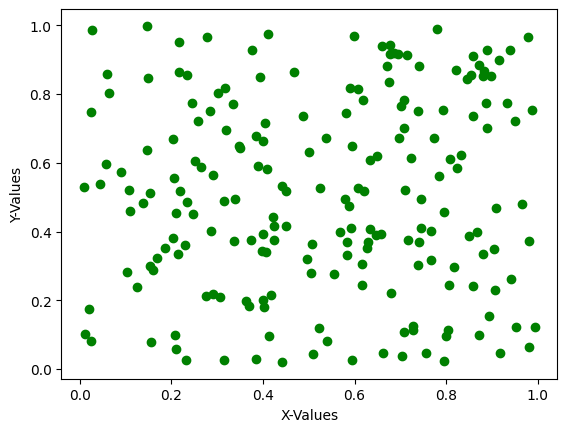

In [ ]:
# Creating a randomised dataset
np.random.seed(5000)
sample_dataset = np.random.rand(200,2) # 20 observations(rows), 2 variables(cols)
X = sample_dataset[:,0]
y = sample_dataset[:,1]
n = len(y)
#print(sample_dataset)

# Plot the original dataset
plt.scatter(X,y, color = "GREEN")
plt.xlabel("X-Values")
plt.ylabel("Y-Values")

# Gradient Descent + Mean Squared Error Cost Function

In [ ]:
"""
Mean squared Error function
A function that takes a y[i] value and takes it away from Beta_0 + Beta_1*X[i] , squares that result,
and then sums up all of the residuals in that particular model ie. for every different parameter.

This helps us to compare different models through parameters. Its derivative is used for gradient descent
in terms of the other parameters.

@param - X = Vector of predictor values - 1D Numpy Array
       - y = Vector of response actual values - 1D Numpy Array
       - Beta_0 = y-Intercept parameter(Bias) - Float
       - Beta_1 = Slope Parameter(Weight) - Float

@return - Mean squared error (MSE) which is the cost function used here.
"""
# Initialise the parameters to 0 start the gradient descent process
Beta_0 = 0
Beta_1 = 0
MSE_costs = []
def cost_function(X, y, Beta_0, Beta_1):
    return np.mean((y-(Beta_0+Beta_1*X))**2)

# learning_rate determines how big a step the algorithm takes. 
# (Too high = divergence and Too low = time-consuming process)

# Epochs are the iterations required for the parameters to be sufficiently optimized.
learning_rate = 0.01
epochs = 1000

# Updating the parameters each iteration 
"""
This algorithm implements gradient descent, which is designed to find the parameters that minimise
the cost function MSE(Mean squared error).

@param ~ X = Vector of predictor values - 1D Numpy array
       - Y = Vector of response values(actual) - 1D Numpy array
       - Beta_0 = Intecept parameter value(bias) Float
       - Beta_1 = Slope parameter value(weight) Float
"""

def gradient_descent(X,y,Beta_0,Beta_1,learning_rate):
    y_hat = Beta_0 + Beta_1 * X
    d_Beta_0 = -(2/n) * np.sum(y-y_hat)
    d_Beta_1 = -(2/n) * np.sum((y-y_hat)*X)

    Beta_0 = Beta_0 - learning_rate * d_Beta_0
    Beta_1 = Beta_1 - learning_rate * d_Beta_1
    return Beta_0,Beta_1
    
# Iterations of the gradient descent in action.
for epoch in range(epochs):
    y_hat = Beta_0 + Beta_1 * X
    Beta_0, Beta_1 = gradient_descent(X,y,Beta_0,Beta_1,learning_rate)
    MSE_costs.append(cost_function(X,y,Beta_0,Beta_1))
    if epoch % 100 == 0: 
        print(f"MSE: {cost:2f}, Intercept: {Beta_0:2f}, Slope: {Beta_1:2f}")

MSE: 0.077541, Intercept: 0.010096, Slope: 0.005427
MSE: 0.077541, Intercept: 0.367935, Slope: 0.183261
MSE: 0.077541, Intercept: 0.401867, Slope: 0.181613
MSE: 0.077541, Intercept: 0.411568, Slope: 0.168583
MSE: 0.077541, Intercept: 0.418740, Slope: 0.156123
MSE: 0.077541, Intercept: 0.425032, Slope: 0.144946
MSE: 0.077541, Intercept: 0.430638, Slope: 0.134969
MSE: 0.077541, Intercept: 0.435640, Slope: 0.126067
MSE: 0.077541, Intercept: 0.440102, Slope: 0.118125
MSE: 0.077541, Intercept: 0.444084, Slope: 0.111038


## Plotting Mean Squared Error

Text(0.5, 1.0, 'Cost function of model over each Epoch')

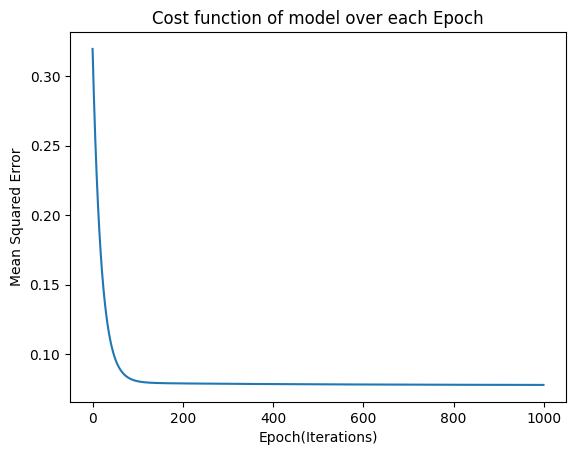

In [ ]:
# Plot the Mean Squared Error (y) vs Epoch
MSE_costs = np.array(MSE_costs)
plt.plot(range(epochs),MSE_costs)
plt.xlabel("Epoch(Iterations)")
plt.ylabel("Mean Squared Error")
plt.title("Cost function of model over each Epoch")

## Linear Regression line plot

Text(0, 0.5, 'y')

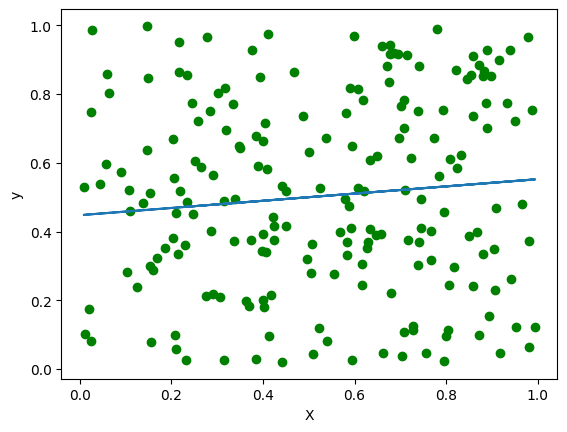

In [ ]:
# Plot the X and y variables with a regression line.
plt.scatter(X,y, color = "Green")
plt.plot(X,Beta_0 + Beta_1*X)
plt.xlabel("X")
plt.ylabel("y")